In [5]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

In [6]:
import os 

# os.chdir("..")
print(os.getcwd())

e:\project_archive\new project


In [7]:
from pathlib import Path 

data_path = Path("data/raw")

if not data_path.exists():
    raise FileNotFoundError

In [8]:
student_data_path = data_path / "student_academic_data" / "data.csv"

if not student_data_path.exists():
    raise FileNotFoundError

In [9]:
df = pd.read_csv(student_data_path, sep=";")

df.sample(10)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
366,1,1,4,9500,1,1,136.0,1,19,38,...,0,7,7,6,14.033333,0,7.6,2.6,0.32,Graduate
4158,1,1,2,9500,1,1,120.0,1,3,37,...,0,8,10,7,12.050000,0,12.4,0.5,1.79,Graduate
1453,1,18,2,9238,1,1,126.0,1,19,37,...,2,6,6,6,11.166667,0,10.8,1.4,1.74,Graduate
3245,1,43,1,9773,1,1,129.0,1,1,1,...,0,6,6,6,12.000000,0,10.8,1.4,1.74,Dropout
3605,1,1,3,9773,1,1,135.0,1,3,1,...,0,6,11,3,12.750000,0,15.5,2.8,-4.06,Graduate
3477,1,43,1,9991,0,1,141.0,1,37,37,...,5,10,17,5,12.400000,0,9.4,-0.8,-3.12,Dropout
464,1,17,1,9238,1,1,148.0,1,1,1,...,0,6,11,4,10.400000,0,15.5,2.8,-4.06,Enrolled
1374,1,7,1,9556,1,3,130.0,1,1,37,...,3,8,8,3,11.333333,4,10.8,1.4,1.74,Dropout
2125,1,43,1,9254,1,1,142.0,1,38,38,...,0,6,11,1,10.000000,0,10.8,1.4,1.74,Dropout
658,1,43,1,9070,1,1,141.0,1,1,19,...,0,6,9,5,12.400000,0,12.7,3.7,-1.70,Graduate


In [10]:
clms = df.columns
print(f"features in the data")
print(clms)

features in the data
Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       

In [11]:
drop_cols = [
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)"
]

In [12]:
drop_temp = ["Application mode"]

df.drop(drop_temp, axis=1)

,Marital status,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,5,171,1,1,122.0,1,19,12,5,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,1,9254,1,1,160.0,1,1,3,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,5,9070,1,1,122.0,1,37,37,9,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,2,9773,1,1,122.0,1,38,37,5,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,1,8014,0,1,100.0,1,37,38,9,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,6,9773,1,1,125.0,1,1,1,5,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,2,9773,1,1,120.0,105,1,1,9,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,9500,1,1,154.0,1,37,37,9,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,9147,1,1,180.0,1,37,37,7,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [13]:
df = df.drop(drop_cols, axis=1)
df.sample()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Unemployment rate,Inflation rate,GDP,Target
3317,1,1,1,171,1,1,172.0,1,1,1,...,0,1,1,1,18,0,16.2,0.3,-0.92,Graduate


In [14]:
print(df.columns)

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International', 'Unemployment rate',
       'Inflation rate', 'GDP', 'Target'],
      dtype='str')


In [15]:
print(f"data size: {df.shape}")

data size: (4424, 25)


In [16]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Marital status                  4424 non-null   int64  
 1   Application mode                4424 non-null   int64  
 2   Application order               4424 non-null   int64  
 3   Course                          4424 non-null   int64  
 4   Daytime/evening attendance	     4424 non-null   int64  
 5   Previous qualification          4424 non-null   int64  
 6   Previous qualification (grade)  4424 non-null   float64
 7   Nacionality                     4424 non-null   int64  
 8   Mother's qualification          4424 non-null   int64  
 9   Father's qualification          4424 non-null   int64  
 10  Mother's occupation             4424 non-null   int64  
 11  Father's occupation             4424 non-null   int64  
 12  Admission grade                 4424 non-null

In [17]:
df.isnull().sum().sort_values(ascending=False)

Marital status                    0
Application mode                  0
Application order                 0
Course                            0
Daytime/evening attendance\t      0
Previous qualification            0
Previous qualification (grade)    0
Nacionality                       0
Mother's qualification            0
Father's qualification            0
Mother's occupation               0
Father's occupation               0
Admission grade                   0
Displaced                         0
Educational special needs         0
Debtor                            0
Tuition fees up to date           0
Gender                            0
Scholarship holder                0
Age at enrollment                 0
International                     0
Unemployment rate                 0
Inflation rate                    0
GDP                               0
Target                            0
dtype: int64

e:\project_archive\new project\venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


<Axes: >

e:\project_archive\new project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


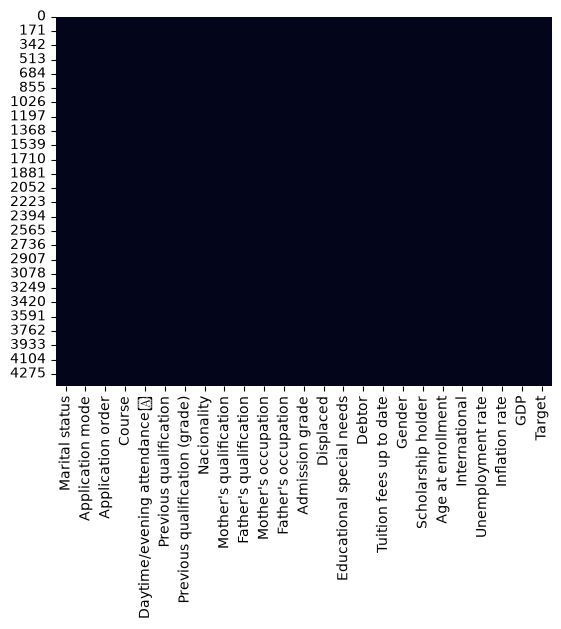

In [18]:
sns.heatmap(df.isnull(), cbar=False)

In [19]:
print("Check duplicate value")
print(set(df.duplicated()))

Check duplicate value
{False}


TARGET VARIABLE ANALYSIS


In [20]:
figures_paths = Path("artifacts/reports/figures")

if not figures_paths.exists():
    raise FileNotFoundError

In [21]:
df['Target'].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [22]:
df["Target"].value_counts(normalize=True)

Target
Graduate    0.499322
Dropout     0.321203
Enrolled    0.179476
Name: proportion, dtype: float64

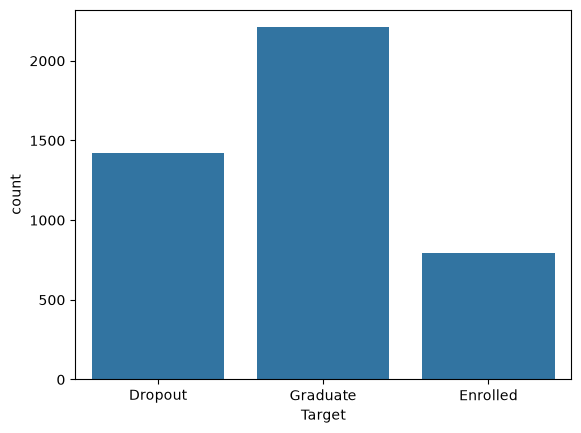

In [23]:
sns.countplot(x="Target", data=df)
target_distribustion_figur_path = figures_paths / "target-distribustion.png" 
plt.savefig(target_distribustion_figur_path, dpi=300, bbox_inches="tight")
plt.show()

ANALYSIS OF UNIVARIATE

Numerical Analysis

In [24]:
import re

def safe_filename(name: str) -> str:
    name = name.strip()          # Removes leading/trailing whitespace and tabs
    name = name.lower()
    name = re.sub(r'[<>:"/\\|?*]+', "_", name)  # Replace invalid filename characters
    name = re.sub(r"\s+", "_", name)            # Replace spaces with underscores
    return name

In [25]:
from pathlib import Path
import matplotlib.pyplot as plt

def save_plot(filename: str, subfolder: str):
    save_dir = figures_paths / subfolder
    save_dir.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        save_dir / filename,
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

In [26]:
num_cols = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

In [27]:
for col in num_cols:
    plt.figure(figsize=(8, 5))

    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    filename = (
        f"{col.lower()}"
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        + "_distribution.png"
    )

    save_plot(filename, subfolder="numerical_analysis")

In [28]:
for col in num_cols:
    plt.figure(figsize=(8, 5))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.ylabel("count")

    filename = (
        f"{col.lower()}"
        .replace(" ","_")
        .replace("(", "")
        .replace(")","")
        + "_boxplot.png"
    )

    save_plot(filename=filename, subfolder="numerical_analysis" )

Categorical Features

In [29]:
cat_cols = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance\t",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

In [30]:
for col in cat_cols:
    print(f"Value count of {col}")
    print(df[col].value_counts())


Value count of Marital status
Marital status
1    3919
2     379
4      91
5      25
6       6
3       4
Name: count, dtype: int64
Value count of Application mode
Application mode
1     1708
17     872
39     785
43     312
44     213
7      139
18     124
42      77
51      59
16      38
53      35
15      30
5       16
10      10
2        3
57       1
26       1
27       1
Name: count, dtype: int64
Value count of Application order
Application order
1    3026
2     547
3     309
4     249
5     154
6     137
9       1
0       1
Name: count, dtype: int64
Value count of Course
Course
9500    766
9147    380
9238    355
9085    337
9773    331
9991    268
9670    268
9254    252
9070    226
171     215
8014    215
9003    210
9853    192
9119    170
9130    141
9556     86
33       12
Name: count, dtype: int64
Value count of Daytime/evening attendance	
Daytime/evening attendance\t
1    3941
0     483
Name: count, dtype: int64
Value count of Previous qualification
Previous qualification
1

In [31]:
for col in cat_cols:
    plt.figure(figsize=(7,5))

    sns.countplot(y=col, data=df)

    plt.title(f"Count plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    filename = f"{safe_filename(col)}_boxplot.png"


    save_plot(filename=filename, subfolder="categorical_analysis")

    

C:\Users\Asus\AppData\Local\Temp\ipykernel_372\3945167156.py:8: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig(


In [32]:
filename = safe_filename("Daytime/evening attendance\t",)
filename

'daytime_evening_attendance'

6. Feature vs Target Analysis ⭐⭐⭐

In [37]:

for col in cat_cols:
  print(f"\n{'='*50}")
  print(col)
  
  print(pd.crosstab(df[col],df["Target"]))

  plt.figure(figsize=(7, 5))

  sns.countplot(x=col,hue="Target",data=df)
  
  plt.title(f"{col} vs target")
  plt.xlabel(col)
  plt.ylabel("count")

  filename = f"{safe_filename(col)}_crosstab.png"


  save_plot(filename=filename, subfolder="categorical_vs_target")
  



Marital status
Target          Dropout  Enrolled  Graduate
Marital status                             
1                  1184       720      2015
2                   179        52       148
3                     1         2         1
4                    42        16        33
5                    11         3        11
6                     4         1         1

Application mode
Target            Dropout  Enrolled  Graduate
Application mode                             
1                     345       300      1063
2                       2         0         1
5                       2         8         6
7                      85         7        47
10                      3         0         7
15                      5        10        15
16                      5         8        25
17                    256       159       457
18                     45        16        63
26                      1         0         0
27                      1         0         0
39              

C:\Users\Asus\AppData\Local\Temp\ipykernel_372\3945167156.py:8: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig(



Previous qualification
Target                  Dropout  Enrolled  Graduate
Previous qualification                             
1                          1078       698      1941
2                            16         1         6
3                            75         4        47
4                             4         1         3
5                             1         0         0
6                             7         1         8
9                            11         0         0
10                            3         0         1
12                           26         6        13
14                            1         0         0
15                            1         0         1
19                          104        13        45
38                            3         1         3
39                           69        55        95
40                           14         6        20
42                            6         8        22
43                            2         

In [ ]:
cat_cols

['Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance\t',
 'Previous qualification',
 'Nacionality',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'International']

In [43]:

for col in cat_cols:
  print(f"\n{'='*50}")
  print(col)
  plt.figure(figsize=(7, 5))

  sns.boxplot(
    x="Target",
    y="Previous qualification (grade)",
    data=df
  )
  
  plt.title(f"{col} vs target")
  plt.xlabel("Target")
  plt.ylabel(col)

  filename = f"{safe_filename(col)}_boxplot.png"
  save_plot(filename=filename, subfolder="categorical_vs_target_boxplot")




Marital status

Application mode

Application order

Course

Daytime/evening attendance	


C:\Users\Asus\AppData\Local\Temp\ipykernel_372\3945167156.py:8: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig(



Previous qualification

Nacionality

Mother's qualification

Father's qualification

Mother's occupation

Father's occupation

Displaced

Educational special needs

Debtor

Tuition fees up to date

Gender

Scholarship holder

International
